<a href="https://colab.research.google.com/github/YYasirahmedd/cyberbullying_detection/blob/main/cyberbullying_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyberbullying Detection Using Machine Learning

This project uses Natural Language Processing (NLP) and Machine Learning to detect cyberbullying comments.
The model is trained using TF-IDF and Logistic Regression to classify text as toxic or non-toxic.


In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [ ]:
# Mount Google Drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Load Dataset from Google Drive

file_path = "/content/drive/MyDrive/Cyberbullying_Project/train.csv"

df = pd.read_csv(file_path, engine="python", on_bad_lines="skip")

print("Dataset Shape:", df.shape)
df.head()



Dataset Shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
# Check Dataset Columns

df.columns



Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [ ]:
# Select Features and Target

X = df["comment_text"]
y = df["toxic"]






In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# Text Vectorization (TF-IDF)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)



In [ ]:
# Train Machine Learning Model

model = LogisticRegression(class_weight="balanced")
model.fit(X_train_tfidf, y_train)



LogisticRegression(class_weight='balanced')

In [ ]:
# Model Evaluation

predictions = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))



Accuracy: 0.9175936080213066

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.93      0.95     28859
           1       0.55      0.84      0.66      3056

    accuracy                           0.92     31915
   macro avg       0.76      0.88      0.81     31915
weighted avg       0.94      0.92      0.93     31915



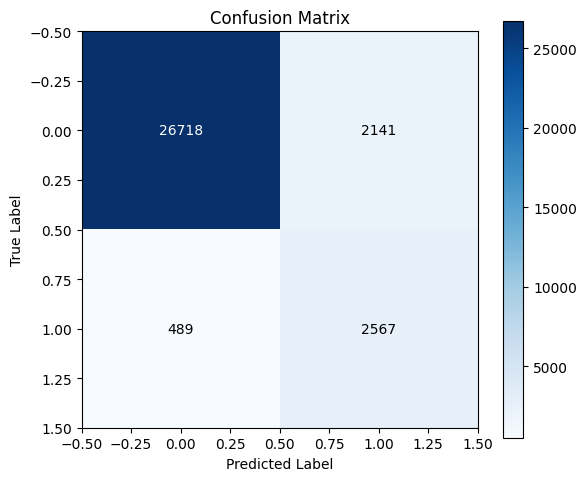

In [ ]:
# Confusion Matrix Visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add values inside cells
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.tight_layout()
plt.show()



In [ ]:
# Real-Time Prediction Function

def predict_comment(text):
    vectorized_text = vectorizer.transform([text])
    prediction = model.predict(vectorized_text)[0]
    probability = model.predict_proba(vectorized_text).max()

    label = "Toxic Comment" if prediction == 1 else "Non-Toxic Comment"
    return label, round(probability * 100, 2)



In [ ]:
# Test the Model

print(predict_comment("you are useless"))
print(predict_comment("have a nice day"))


('Toxic Comment', np.float64(84.22))
('Non-Toxic Comment', np.float64(68.01))


## Conclusion

This project demonstrates an effective approach to detecting cyberbullying using machine learning and NLP.
The model can be extended using deep learning techniques and deployed as a real-time moderation system.
